In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIRECTORY = PROJECT_ROOT / "artifacts" / "results"
IMAGES_DIRECTORY = PROJECT_ROOT / "data" / "raw" / "SPAQ_small"
MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_manifest.csv"

RANDOM_STATE = 42

summary_files = [
    path
    for path in RESULTS_DIRECTORY.glob("*_metrics.csv")
    if not path.name.endswith("_metrics_by_target.csv")
]

print("Знайдено файлів:", len(summary_files))
for path in summary_files:
    print(path.name)


Знайдено файлів: 3
custom_cnn_metrics.csv
resnet_feature_extraction_metrics.csv
resnet_fine_tuning_metrics.csv


Таблиця порівняння метрик

In [17]:
comparison_dataframe = pd.concat(
    [pd.read_csv(path) for path in summary_files],
    ignore_index=True,
)

comparison_dataframe = comparison_dataframe.sort_values("mae")

display(comparison_dataframe.round({
    "mae": 3, "rmse": 3, "plcc": 4, "srcc": 4,
    "validation_loss": 6, "training_time_seconds": 1,
}))

comparison_dataframe.to_csv(
    RESULTS_DIRECTORY / "final_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,training_strategy,mae,rmse,plcc,srcc,best_epoch,validation_loss,training_time_seconds,total_parameters,trainable_parameters
2,ResNet18,Fine-tuning layer4,8.467,10.797,0.8643,0.8587,7,0.013193,1196.0,11179590,8396806
0,Custom CNN,Custom CNN,8.884,11.303,0.8469,0.8415,7,0.012794,1383.0,423046,423046
1,ResNet18,Feature Extraction,10.624,13.342,0.7835,0.7803,4,0.017718,909.9,11179590,3078


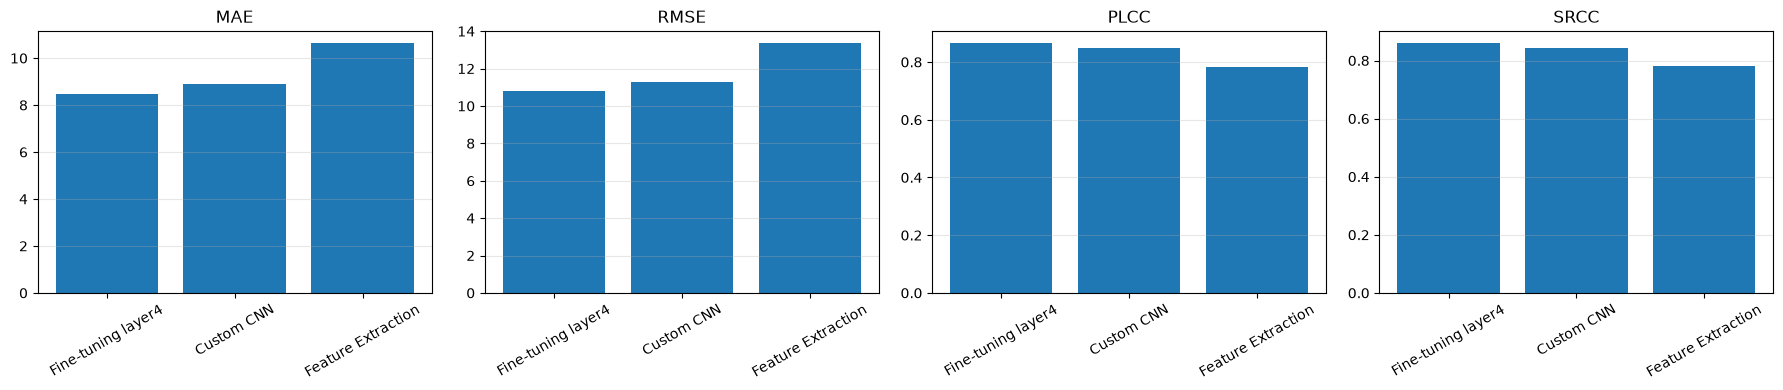

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

labels = comparison_dataframe["training_strategy"]

metrics_to_plot = [
    ("mae", "MAE"),
    ("rmse", "RMSE"),
    ("plcc", "PLCC"),
    ("srcc", "SRCC"),
]

for axis, (column, title) in zip(axes, metrics_to_plot):
    axis.bar(labels, comparison_dataframe[column])
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=30)
    axis.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULTS_DIRECTORY / "final_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()

Найкраща модель

In [19]:
best_model = comparison_dataframe.iloc[0]

print("Найкраща модель за MAE:", best_model["model"], "-", best_model["training_strategy"])
print(f"MAE: {best_model['mae']:.3f}")
print(f"RMSE: {best_model['rmse']:.3f}")
print(f"PLCC: {best_model['plcc']:.4f}")
print(f"SRCC: {best_model['srcc']:.4f}")
print(f"Навчуваних параметрів: {best_model['trainable_parameters']:,}")
print(f"Час навчання: {best_model['training_time_seconds']/60:.1f} хв")

Найкраща модель за MAE: ResNet18 - Fine-tuning layer4
MAE: 8.467
RMSE: 10.797
PLCC: 0.8643
SRCC: 0.8587
Навчуваних параметрів: 8,396,806
Час навчання: 19.9 хв


Криві навчання (Train vs Validation Loss)

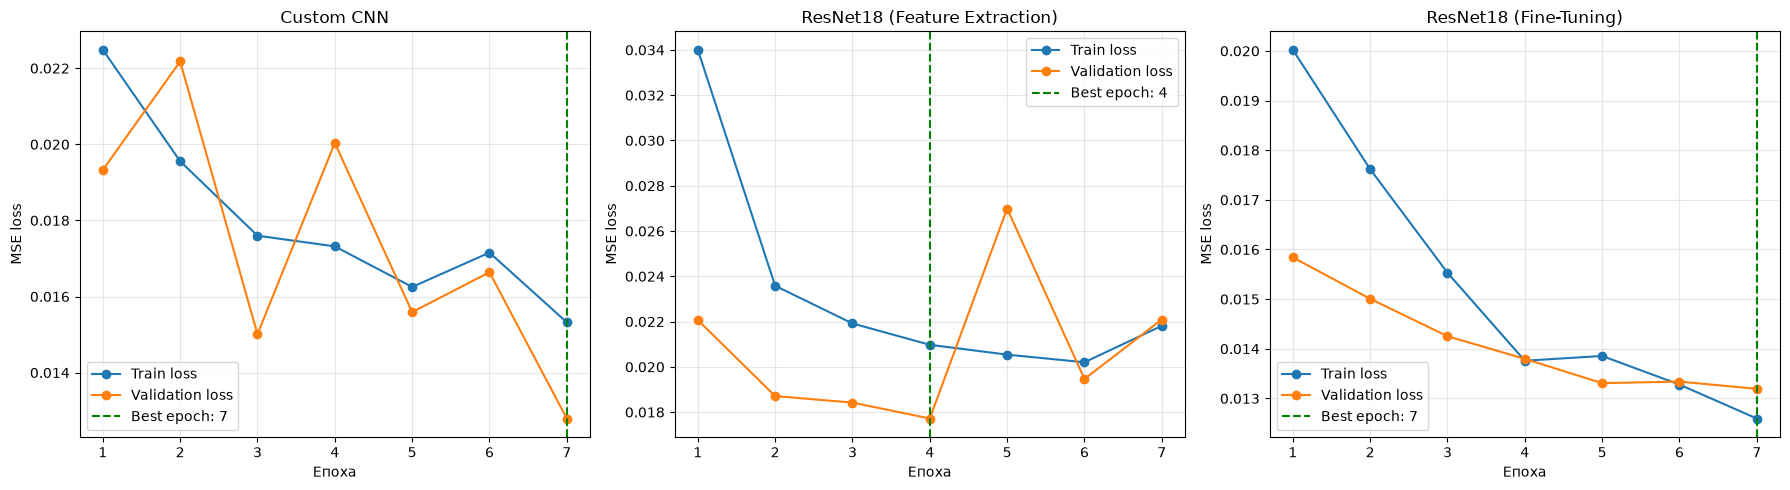

In [20]:
MODEL_PREFIXES = ["custom_cnn", "resnet_feature_extraction", "resnet_fine_tuning"]

MODEL_DISPLAY_NAMES = {
    "custom_cnn": "Custom CNN",
    "resnet_feature_extraction": "ResNet18 (Feature Extraction)",
    "resnet_fine_tuning": "ResNet18 (Fine-Tuning)",
}

fig, axes = plt.subplots(1, len(MODEL_PREFIXES), figsize=(18, 5), sharey=False)

for axis, prefix in zip(axes, MODEL_PREFIXES):
    history_path = RESULTS_DIRECTORY / f"{prefix}_history.csv"

    if not history_path.exists():
        axis.set_title(f"{MODEL_DISPLAY_NAMES[prefix]}\n(немає history.csv)")
        continue

    history_dataframe = pd.read_csv(history_path)
    best_epoch = history_dataframe.loc[
        history_dataframe["validation_loss"].idxmin(), "epoch"
    ]

    axis.plot(
        history_dataframe["epoch"],
        history_dataframe["train_loss"],
        marker="o",
        label="Train loss",
    )
    axis.plot(
        history_dataframe["epoch"],
        history_dataframe["validation_loss"],
        marker="o",
        label="Validation loss",
    )
    axis.axvline(
        best_epoch,
        color="green",
        linestyle="--",
        label=f"Best epoch: {best_epoch}",
    )

    axis.set_title(MODEL_DISPLAY_NAMES[prefix])
    axis.set_xlabel("Епоха")
    axis.set_ylabel("MSE loss")
    axis.legend()
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIRECTORY / "final_loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Найгірші прогнози

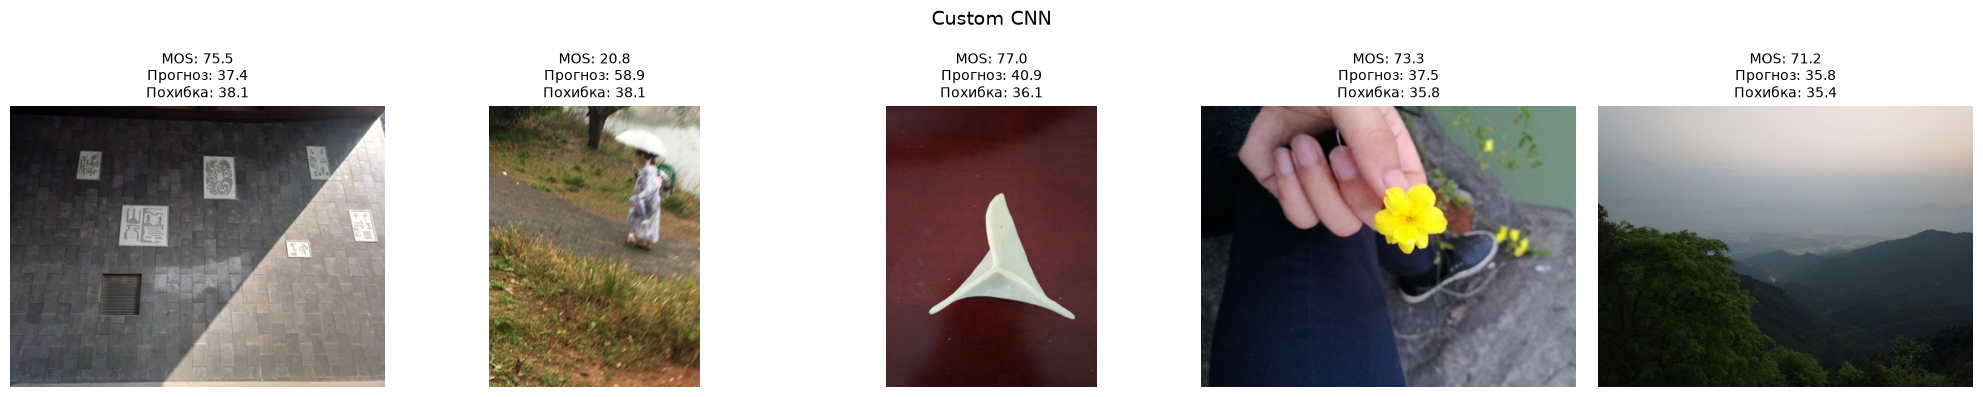

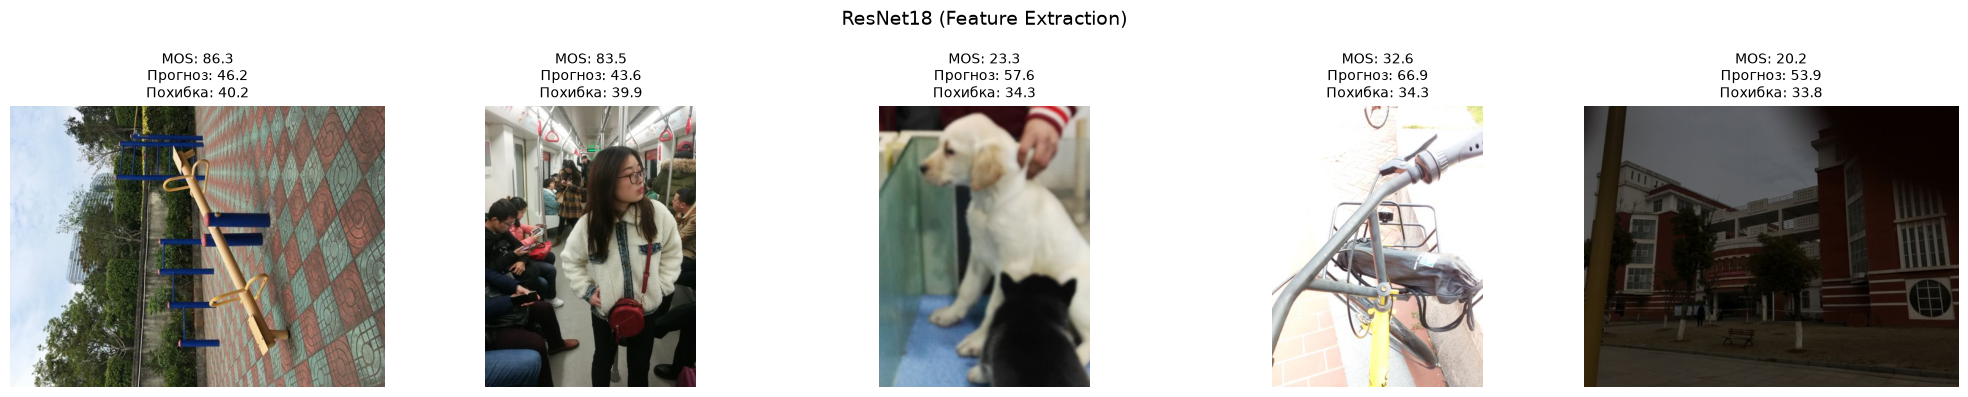

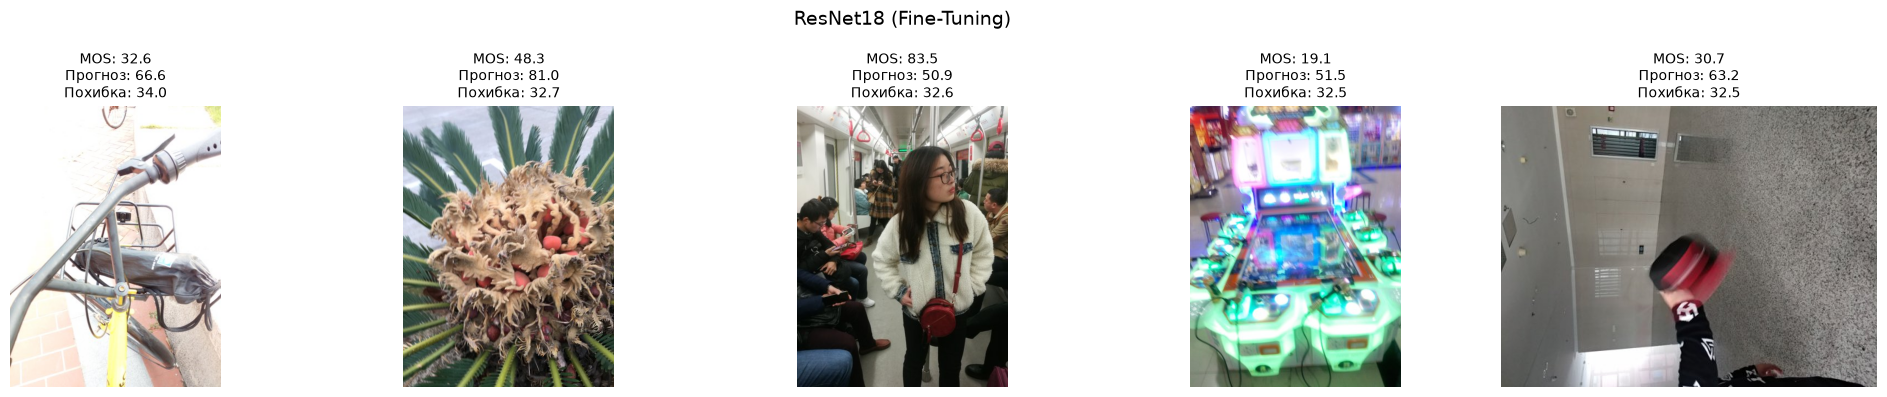

In [21]:
IMAGES_DIRECTORY = PROJECT_ROOT / "data" / "raw" / "SPAQ_small"
N_WORST = 5

for prefix in MODEL_PREFIXES:
    predictions_path = RESULTS_DIRECTORY / f"{prefix}_predictions.csv"

    if not predictions_path.exists():
        print(f"{MODEL_DISPLAY_NAMES[prefix]}: немає predictions.csv, пропускаю")
        continue

    predictions_dataframe = pd.read_csv(predictions_path)

    worst_predictions = (
        predictions_dataframe
        .sort_values("overall_error", ascending=False)
        .head(N_WORST)
    )

    figure, axes = plt.subplots(1, N_WORST, figsize=(4 * N_WORST, 4))
    figure.suptitle(MODEL_DISPLAY_NAMES[prefix], fontsize=14)

    for axis, (_, row) in zip(axes, worst_predictions.iterrows()):
        image_path = IMAGES_DIRECTORY / row["image_name"]

        with Image.open(image_path) as image:
            axis.imshow(image.convert("RGB"))

        axis.set_title(
            f'MOS: {row["true_overall_quality"]:.1f}\n'
            f'Прогноз: {row["predicted_overall_quality"]:.1f}\n'
            f'Похибка: {row["overall_error"]:.1f}',
            fontsize=10,
        )
        axis.axis("off")

    plt.tight_layout()
    plt.savefig(
        RESULTS_DIRECTORY / f"{prefix}_worst_predictions.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()


In [23]:
IMAGE_COLUMN = "image_name"
TARGET_COLUMN = "overall_quality"

data = pd.read_csv(MANIFEST_PATH)

required_columns = {IMAGE_COLUMN, TARGET_COLUMN, "split"}
missing_columns = required_columns - set(data.columns)

if missing_columns:
    raise ValueError("У dataset_manifest.csv відсутні колонки: {f'{sorted(missing_columns)}'}")

train_full = data[data["split"] == "train"].copy()
test_full = data[data["split"] == "test"].copy()

train_dataframe = train_full.sample(n=3000,random_state=RANDOM_STATE).reset_index(drop=True)

test_dataframe = test_full.sample(n=600,random_state=RANDOM_STATE,).reset_index(drop=True)

if train_dataframe[TARGET_COLUMN].max() <= 1:
    train_dataframe[TARGET_COLUMN] *= 100
    test_dataframe[TARGET_COLUMN] *= 100

baseline_mean = train_dataframe[TARGET_COLUMN].mean()
baseline_predictions = np.full(shape=len(test_dataframe), fill_value=baseline_mean)

baseline_mae = mean_absolute_error(test_dataframe[TARGET_COLUMN],baseline_predictions)
baseline_rmse = np.sqrt(
    mean_squared_error(test_dataframe[TARGET_COLUMN],baseline_predictions)
)

print(f"Навчальна підвибірка: {len(train_dataframe)} фотографій")
print(f"Тестова підвибірка: {len(test_dataframe)} фотографій")
print(f"Середнє значення для baseline: {baseline_mean:.2f}")
print(f"Baseline MAE: {baseline_mae:.3f}")
print(f"Baseline RMSE: {baseline_rmse:.3f}")


Навчальна підвибірка: 3000 фотографій
Тестова підвибірка: 600 фотографій
Середнє значення для baseline: 50.39
Baseline MAE: 18.476
Baseline RMSE: 21.199


Вирівнювання по одних і тих самих фото

In [25]:
predictions = {}

for prefix in MODEL_PREFIXES:
    predictions_path = RESULTS_DIRECTORY / f"{prefix}_predictions.csv"
    predictions_dataframe = pd.read_csv(predictions_path).set_index("image_name")
    predictions[prefix] = predictions_dataframe

common_images = sorted(
    set.intersection(*[set(predictions_dataframe.index)for predictions_dataframe in predictions.values()])
)

print("Спільних тестових фото:", len(common_images))

y_true = predictions[MODEL_PREFIXES[0]].loc[common_images,"true_overall_quality",].to_numpy()

y_pred = {
    prefix: predictions[prefix].loc[common_images,"predicted_overall_quality"].to_numpy()
    for prefix in MODEL_PREFIXES
}

y_pred["dummy"] = np.full_like(y_true, baseline_mean)

NAMES = {**MODEL_DISPLAY_NAMES,"dummy": "Baseline (середнє)"}

Спільних тестових фото: 600


Bootstrap: довірчі інтервали і чи значуща різниця між моделями

In [26]:
rng = np.random.default_rng(42)
N_BOOT = 2000

idx = rng.integers(0, len(y_true), size=(N_BOOT, len(y_true)))

def mae(t, p):
    return np.abs(t - p).mean()

def plcc(t, p):
    return pearsonr(t, p)[0]

rows = []

for model_key, model_predictions in y_pred.items():
    bootstrap_mae = np.array([mae(y_true[i], model_predictions[i]) for i in idx
    ])

    row = {
        "model": NAMES[model_key],
        "MAE": mae(y_true, model_predictions),
        "MAE 95% CI": (
            f"[{np.percentile(bootstrap_mae, 2.5):.2f}; "
            f"{np.percentile(bootstrap_mae, 97.5):.2f}]"
        ),
    }

    if model_key != "dummy":
        bootstrap_plcc = np.array([
            plcc(y_true[i], model_predictions[i]) for i in idx
        ])

        row["PLCC"] = plcc(y_true, model_predictions)
        row["PLCC 95% CI"] = (
            f"[{np.percentile(bootstrap_plcc, 2.5):.3f}; "
            f"{np.percentile(bootstrap_plcc, 97.5):.3f}]"
        )

    rows.append(row)

ci_table = pd.DataFrame(rows).round(3)
display(ci_table)

,model,MAE,MAE 95% CI,PLCC,PLCC 95% CI
0,Custom CNN,8.884,[8.32; 9.44],0.847,[0.823; 0.870]
1,ResNet18 (Feature Extraction),10.624,[9.99; 11.29],0.783,[0.753; 0.812]
2,ResNet18 (Fine-Tuning),8.467,[7.92; 9.02],0.864,[0.844; 0.883]
3,Baseline (середнє),18.476,[17.68; 19.29],NaN,NaN


Різниця MAE

In [27]:
def paired(model_a, model_b):
    differences = np.array([
        mae(y_true[i], y_pred[model_a][i])
        - mae(y_true[i], y_pred[model_b][i])
        for i in idx
    ])

    lower_bound, upper_bound = np.percentile(differences, [2.5, 97.5])

    mae_difference = (
        mae(y_true, y_pred[model_a])
        - mae(y_true, y_pred[model_b])
    )

    result = (
        "різниця значуща"
        if lower_bound > 0 or upper_bound < 0
        else "різниця НЕ значуща (інтервал містить 0)"
    )

    print(
        f"{NAMES[model_a]} - {NAMES[model_b]}: "
        f"ΔMAE = {mae_difference:+.3f}, "
        f"95% CI [{lower_bound:+.3f}; {upper_bound:+.3f}] -> {result}"
    )


paired("resnet_fine_tuning", "custom_cnn")
paired("resnet_feature_extraction", "custom_cnn")
paired("resnet_feature_extraction", "resnet_fine_tuning")

ResNet18 (Fine-Tuning) - Custom CNN: ΔMAE = -0.417, 95% CI [-1.091; +0.194] -> різниця НЕ значуща (інтервал містить 0)
ResNet18 (Feature Extraction) - Custom CNN: ΔMAE = +1.740, 95% CI [+1.015; +2.442] -> різниця значуща
ResNet18 (Feature Extraction) - ResNet18 (Fine-Tuning): ΔMAE = +2.157, 95% CI [+1.610; +2.695] -> різниця значуща


Прогноз проти реальної оцінки і нахил регресії

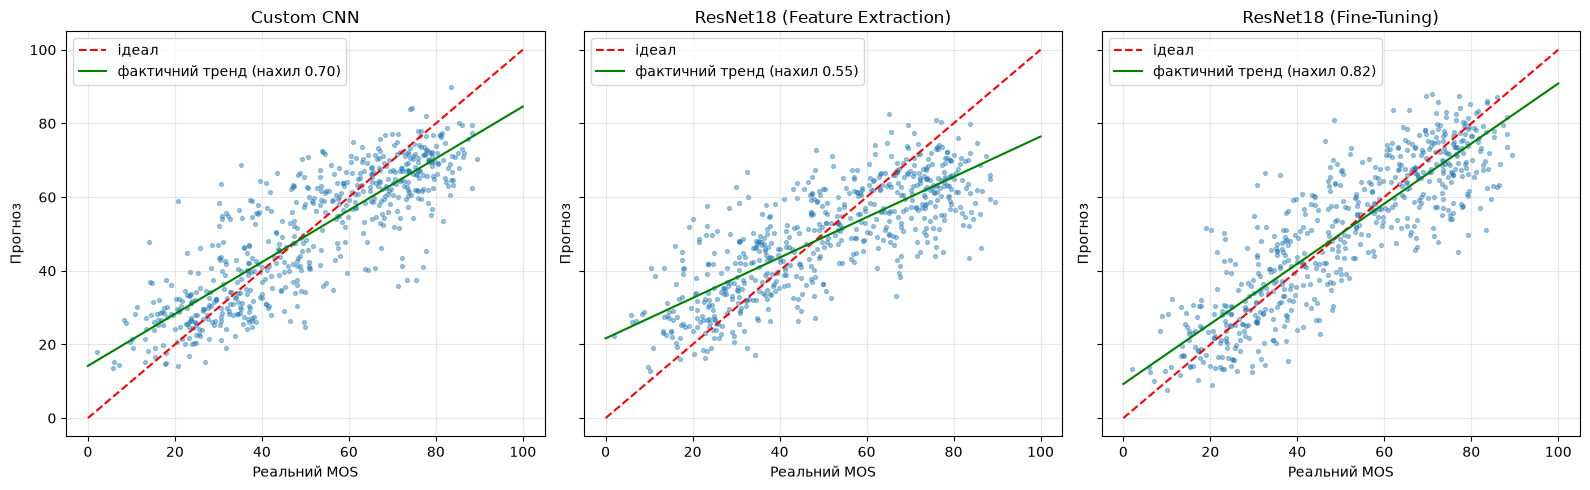

In [28]:
fig, axes = plt.subplots(
    1, 3, figsize=(16, 5),
    sharex=True, sharey=True,
)

for axis, model_key in zip(axes, MODEL_PREFIXES):
    axis.scatter(y_true, y_pred[model_key], s=8, alpha=0.4)
    axis.plot([0, 100], [0, 100], "r--", label="ідеал")

    slope, intercept = np.polyfit(y_true, y_pred[model_key], 1)

    axis.plot(
        [0, 100],
        [intercept, intercept + slope * 100],
        "g-",
        label=f"фактичний тренд (нахил {slope:.2f})",
    )

    axis.set_title(NAMES[model_key])
    axis.set_xlabel("Реальний MOS")
    axis.set_ylabel("Прогноз")
    axis.legend()
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    RESULTS_DIRECTORY / "pred_vs_true.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

Похибка за рівнем якості фото, де моделі помиляються найбільше

,Custom CNN,ResNet18 (Feature Extraction),ResNet18 (Fine-Tuning),к-сть фото
0-25,9.06,12.79,8.03,91
25-40,8.44,8.55,8.44,133
40-55,9.09,7.87,9.39,112
55-70,6.60,8.31,7.03,116
70-100,10.82,15.06,9.18,148


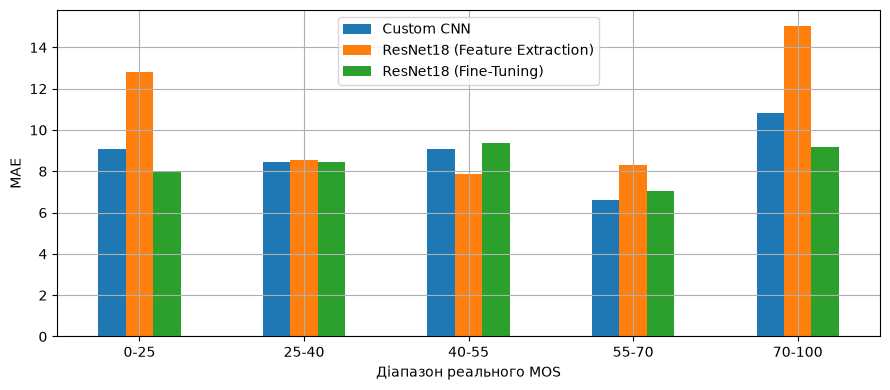

In [29]:
bins = [0, 25, 40, 55, 70, 100]
labels = ["0-25", "25-40", "40-55", "55-70", "70-100"]

bin_idx = pd.cut(
    y_true,
    bins=bins,
    labels=labels,
    include_lowest=True,
)

by_bin = pd.DataFrame({
    NAMES[model_key]: (
        pd.Series(np.abs(y_true - y_pred[model_key]))
        .groupby(bin_idx, observed=True)
        .mean()
    )
    for model_key in MODEL_PREFIXES
})

by_bin["к-сть фото"] = (
    pd.Series(bin_idx)
    .value_counts()
    .reindex(labels)
    .values
)

display(by_bin.round(2))

by_bin.drop(columns="к-сть фото").plot(
    kind="bar",
    figsize=(9, 4),
    rot=0,
    grid=True,
)

plt.ylabel("MAE")
plt.xlabel("Діапазон реального MOS")
plt.tight_layout()
plt.savefig(
    RESULTS_DIRECTORY / "error_by_quality_bin.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

Порівняння за окремими параметрами

In [30]:
target_files = {
    prefix: RESULTS_DIRECTORY / f"{prefix}_metrics_by_target.csv"
    for prefix in MODEL_PREFIXES
}

by_target = {
    prefix: pd.read_csv(path)
    for prefix, path in target_files.items()
    if path.exists()
}

print(list(by_target.values())[0].columns.tolist())

TARGET_COL = "target_column"
MAE_COL = "mae"

pivot = pd.DataFrame({
    NAMES[prefix]: dataframe.set_index(TARGET_COL)[MAE_COL]
    for prefix, dataframe in by_target.items()
})

pivot["найкраща модель"] = pivot.idxmin(axis=1)

display(pivot.round(3))

['target_column', 'parameter', 'mae', 'rmse', 'plcc', 'srcc']


,Custom CNN,ResNet18 (Feature Extraction),ResNet18 (Fine-Tuning),найкраща модель
target_column,,,,
overall_quality,8.884,10.624,8.467,ResNet18 (Fine-Tuning)
brightness_quality,8.100,10.250,8.806,Custom CNN
colorfulness_quality,8.079,9.214,7.850,ResNet18 (Fine-Tuning)
contrast_quality,7.992,9.568,8.214,Custom CNN
noise_quality,9.587,10.772,9.706,Custom CNN
sharpness_quality,9.992,12.355,9.430,ResNet18 (Fine-Tuning)


Кореляція між самими цільовими оцінками SPAQ

,overall_quality,brightness_quality,colorfulness_quality,contrast_quality,noise_quality,sharpness_quality
overall_quality,1.00,0.77,0.83,0.86,0.89,0.96
brightness_quality,0.77,1.00,0.88,0.90,0.73,0.67
colorfulness_quality,0.83,0.88,1.00,0.92,0.80,0.75
contrast_quality,0.86,0.90,0.92,1.00,0.82,0.79
noise_quality,0.89,0.73,0.80,0.82,1.00,0.87
sharpness_quality,0.96,0.67,0.75,0.79,0.87,1.00


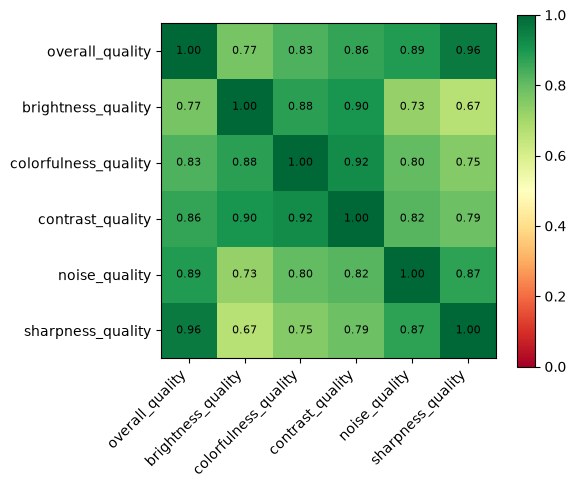

In [31]:
labels_dataframe = pd.read_csv(MANIFEST_PATH)

score_columns = [
    column
    for column in labels_dataframe.columns
    if column.endswith("_quality") or column.lower() == "mos"
]

correlation_matrix = labels_dataframe[score_columns].corr()

display(correlation_matrix.round(2))

plt.figure(figsize=(6, 5))
plt.imshow(correlation_matrix, cmap="RdYlGn", vmin=0, vmax=1)

plt.xticks(
    range(len(score_columns)),
    score_columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(score_columns)),
    score_columns,
)

for row_index in range(len(score_columns)):
    for column_index in range(len(score_columns)):
        plt.text(
            column_index,
            row_index,
            f"{correlation_matrix.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.colorbar()
plt.tight_layout()
plt.savefig(
    RESULTS_DIRECTORY / "targets_correlation.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()